# Desafío 3 — Modelo de lenguaje por caracteres
**Procesamiento de Lenguaje Natural — Lourdes Tolotto**

Se comparan SimpleRNN, LSTM y GRU sobre *La vuelta al mundo en 80 días*, de Julio Verne. Se selecciona el modelo con menor perplejidad de validación y se generan continuaciones con greedy search, beam search determinístico y beam search estocástico, analizando el efecto de la temperatura.

### Consigna
- Seleccionar un corpus de texto para entrenar un modelo de lenguaje.
- Preprocesar y tokenizar el corpus, estructurar el dataset y separar entrenamiento y validación.
- Proponer arquitecturas basadas en unidades recurrentes.
- Generar secuencias con greedy search y beam search determinístico y estocástico. Observar el efecto de la temperatura en el último caso.

### Decisiones del experimento
Se comparan las tres arquitecturas sugeridas: SimpleRNN (celda de Elman), LSTM y GRU. Se usa RMSprop y se controla la perplejidad de validación para detener el entrenamiento. En PyTorch, ese control se implementa en el bucle de entrenamiento en lugar de usar un callback de Keras.

## 1. Librerías y configuración
Se fija una semilla para facilitar la reproducción. Se utiliza CUDA cuando está disponible. El máximo es de 50 épocas, con detención si la perplejidad no mejora durante 5 épocas; al finalizar se restauran siempre los mejores pesos.

No se instala ni modifica ningún paquete desde este notebook. El conflicto OpenMP del entorno debe estar resuelto antes de ejecutarlo.

In [1]:
import re
import time
import json
import hashlib
import sys
import unicodedata
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
from IPython.display import display
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CONTEXT = 100
STRIDE = 20
BATCH_SIZE = 128
EPOCHS = 50
PATIENCE = 5
EMBED_DIM = 32
HIDDEN_SIZE = 128
LEARNING_RATE = 0.001
REENTRENAR = False
OUTPUT_DIR = Path("resultados_desafio3_limpio")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("Dispositivo:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("Prueba CUDA:", torch.ones(3, device=device) * 2)
else:
    print("GPU no disponible")

Python: c:\Users\tolot\anaconda3\envs\pln_clean\python.exe
PyTorch: 2.9.1+cu128
Dispositivo: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
Prueba CUDA: tensor([2., 2., 2.], device='cuda:0')


## 2. Corpus y preprocesamiento
Se utiliza *La vuelta al mundo en 80 días*, de Julio Verne, del sitio textos.info. Se conservan letras, tildes, espacios y puntuación; se convierte a minúsculas y se unifican espacios.

Para excluir encabezados y el pie de página del sitio, se conserva el texto entre el comienzo y la última oración de la novela, identificados en el corpus revisado. Si esos límites no aparecen, se detiene la ejecución para revisar la fuente en lugar de entrenar sobre contenido incorrecto.

Si existe `corpus.txt` se lee ese archivo en UTF-8; debe contener esta misma obra. En caso contrario se descarga la página. Se guarda una copia del corpus limpio para poder reproducir el experimento.

In [2]:
corpus_path = Path("corpus.txt")

if corpus_path.exists():
    raw_text = corpus_path.read_text(encoding="utf-8")
else:
    url = "https://www.textos.info/julio-verne/la-vuelta-al-mundo-en-80-dias/ebook"
    with urllib.request.urlopen(url, timeout=60) as response:
        soup = BeautifulSoup(response.read(), "html.parser")
    raw_text = " ".join(p.get_text(" ", strip=True) for p in soup.find_all("p"))

text = unicodedata.normalize("NFC", raw_text).lower()
text = re.sub(r"\s+", " ", text).strip()

# Límites verificados en la obra seleccionada.
start_marker = "en el año 1872, la casa número 7 de saville-row"
end_marker = "¿no se daría por menos que eso la vuelta al mundo?"
start = text.find(start_marker)
end = text.rfind(end_marker)
if start < 0 or end < start:
    raise ValueError("No se encontraron los límites del libro. Revisar corpus.txt o la página.")

original_length = len(text)
text = text[start:end + len(end_marker)].strip()
assert len(text) > 10 * (CONTEXT + 1), "El corpus es demasiado corto."
assert "textos.info es un proyecto" not in text

_ = (OUTPUT_DIR / "corpus_limpio.txt").write_text(text, encoding="utf-8")
print(f"Caracteres del libro: {len(text):,}")
print("Caracteres externos eliminados:", original_length - len(text))
print("\nINICIO:\n", text[:500])
print("\nFINAL:\n", text[-500:])

Caracteres del libro: 390,192
Caracteres externos eliminados: 564

INICIO:
 en el año 1872, la casa número 7 de saville-row, burlington gardens —donde murió sheridan en 1814— estaba habitada por phileas fogg, quien a pesar de que parecía haber tomado el partido de no hacer nada que pudiese llamar la atención, era uno de los miembros más notables y singulares del reformclub de londres. por consiguiente, phileas fogg, personaje enigmático y del cual sólo se sabía que era un hombre muy galante y de los más cumplidos gentlemen de la alta sociedad inglesa, sucedía a uno de l

FINAL:
  para ello todos los medios de transporte, vapores, ferrocarriles, coches, yatchs, buques mercantes, trineos, elefantes. el excéntrico caballero había desplegado en este negocio sus maravillosas cualidades de serenidad y exactitud. pero, ¿qué había ganado con esa excursión? ¿qué había traído de su viaje? nada, se dirá. nada, enhorabuena, a no ser una linda mujer, que, por inverosímil que parezca, le hizo el más

## 3. Separación y tokenización
Se va a reservar el último 10% del texto para validar **antes de construir las ventanas**. De esta forma, ninguna ventana de entrenamiento cruza al texto de validación.

El vocabulario se construye con entrenamiento. Se reserva el índice 0 para un carácter desconocido (`<UNK>`), en caso de que la validación contenga algún símbolo nuevo. Los índices son identificadores, no valores numéricos con significado.

In [3]:
split = int(len(text) * 0.9)
train_text = text[:split]
val_text = text[split:]

chars = sorted(set(train_text))
char2idx = {char: i + 1 for i, char in enumerate(chars)}
idx2char = {i: char for char, i in char2idx.items()}
idx2char[0] = "<UNK>"
vocab_size = len(chars) + 1

train_ids = np.array([char2idx[c] for c in train_text], dtype=np.int32)
val_ids = np.array([char2idx.get(c, 0) for c in val_text], dtype=np.int32)

print("Tamaño del vocabulario (incluye UNK):", vocab_size)
print("Caracteres de entrenamiento:", len(train_ids))
print("Caracteres de validación:", len(val_ids))
print("Caracteres desconocidos en validación:", np.sum(val_ids == 0))

Tamaño del vocabulario (incluye UNK): 65
Caracteres de entrenamiento: 351172
Caracteres de validación: 39020
Caracteres desconocidos en validación: 0


## 4. Secuencias de entrada y objetivo
De cada bloque de 101 caracteres se obtiene una entrada de 100 y un objetivo de 100, desplazado una posición. Por ejemplo, de `el gato` obtenemos `el gat` como entrada y `l gato` como objetivo.

El modelo produce una predicción por posición (**many-to-many**). En entrenamiento se avanza 20 caracteres entre ventanas para reducir tiempo y redundancia respecto de avanzar uno. En validación se avanza de a 100: cada carácter objetivo evaluado se cuenta una sola vez. Se descarta únicamente el tramo final que no alcanza para una ventana completa.

`unfold` crea una vista de las ventanas y `DataLoader` arma los lotes. Se usa `num_workers=0` para mantener la ejecución simple en notebooks de Windows.

In [4]:
def make_loader(ids, stride, shuffle=False):
    tokens = torch.tensor(ids, dtype=torch.long)
    windows = tokens.unfold(0, CONTEXT + 1, stride)
    dataset = TensorDataset(windows[:, :-1], windows[:, 1:])
    return DataLoader(dataset, batch_size=BATCH_SIZE,
                      shuffle=shuffle, num_workers=0)

train_loader = make_loader(train_ids, STRIDE, shuffle=True)
val_loader = make_loader(val_ids, CONTEXT)

x_batch, y_batch = next(iter(train_loader))
print("Forma de X:", x_batch.shape)
print("Forma de y:", y_batch.shape)
print("Entrada:", "".join(idx2char[int(i)] for i in x_batch[0]))
print("Objetivo:", "".join(idx2char[int(i)] for i in y_batch[0]))
assert torch.equal(x_batch[:, 1:], y_batch[:, :-1])

Forma de X: torch.Size([128, 100])
Forma de y: torch.Size([128, 100])
Entrada: un absoluto silencio en la llanura, cuya infinita calma no era turbada ni por el vuelo de las aves n
Objetivo: n absoluto silencio en la llanura, cuya infinita calma no era turbada ni por el vuelo de las aves ni


## 5. Arquitecturas y perplejidad
Los tres modelos tienen un embedding de 32 dimensiones, una capa recurrente de 128 unidades y una capa lineal con un puntaje (logit) por carácter. Se mantienen los demás ajustes iguales; las arquitecturas tienen distinta cantidad de parámetros, por lo que la comparación también considera el costo de cada modelo.

El embedding aprende una representación de cada carácter. Las capas recurrentes devuelven salidas para todas las posiciones. `CrossEntropyLoss` recibe logits y se aplica softmax solo al generar texto.

Se usa RMSprop. La perplejidad por carácter es:

$$\mathrm{PPL} = \exp(\mathrm{entropía\ cruzada\ media})$$

La pérdida se promedia sobre los caracteres objetivo, ponderando cada lote por su cantidad de tokens. Una menor perplejidad indica una mejor predicción de los caracteres correctos, pero no garantiza coherencia narrativa.

Se controla directamente la perplejidad de validación: si no mejora durante 5 épocas, se detiene el entrenamiento. Al finalizar, por paciencia o por el máximo de épocas, se restauran siempre los mejores pesos. Esto equivale a seleccionar por pérdida de validación, ya que la exponencial es creciente.

In [5]:
class CharModel(nn.Module):
    def __init__(self, cell_type):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, EMBED_DIM)
        recurrent_layer = {"SimpleRNN": nn.RNN, "LSTM": nn.LSTM, "GRU": nn.GRU}[cell_type]
        self.recurrent = recurrent_layer(EMBED_DIM, HIDDEN_SIZE, batch_first=True)
        self.output = nn.Linear(HIDDEN_SIZE, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        sequence, _ = self.recurrent(x)
        return self.output(sequence)


criterion = nn.CrossEntropyLoss()


def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss, total_tokens = 0.0, 0

    with torch.set_grad_enabled(training):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if training:
                optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits.reshape(-1, vocab_size), y.reshape(-1))

            if training:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item() * y.numel()
            total_tokens += y.numel()

    return total_loss / total_tokens

## 6. Entrenamiento, guardado y comparación
La sección tiene tres pasos: comprobar resultados guardados, entrenar o cargar y finalmente graficar y seleccionar el mejor modelo.

Se verifica una huella del corpus y la configuración del experimento antes de reutilizar resultados. `REENTRENAR=True` fuerza una nueva ejecución. Los archivos de esta versión están en una carpeta separada de los modelos anteriores.

Los mejores pesos se guardan en disco cada vez que mejora la perplejidad. También se guarda el historial de cada época. Solo se permite la carga automática del experimento completo si terminó el entrenamiento de los tres modelos.

La validación se utiliza para detener y seleccionar modelos; no es un conjunto de test independiente.

In [6]:
config = {
    "corpus_sha256": hashlib.sha256(text.encode("utf-8")).hexdigest(),
    "train_fraction": 0.9,
    "context": CONTEXT,
    "stride": STRIDE,
    "batch_size": BATCH_SIZE,
    "max_epochs": EPOCHS,
    "patience": PATIENCE,
    "embedding": EMBED_DIM,
    "hidden_size": HIDDEN_SIZE,
    "optimizer": "RMSprop",
    "learning_rate": LEARNING_RATE,
    "clip_norm": 1.0,
    "seed": SEED,
    "torch_version": str(torch.__version__),
    "device": str(device),
    "models": ["SimpleRNN", "LSTM", "GRU"],
}

config_path = OUTPUT_DIR / "config.json"
required_files = [
    "SimpleRNN.pt", "LSTM.pt", "GRU.pt", "comparacion_modelos.csv",
    "historial_entrenamiento.json", "config.json",
]
saved_config = json.loads(config_path.read_text(encoding="utf-8")) if config_path.exists() else None
entrenar = (
    REENTRENAR
    or saved_config != config
    or not all((OUTPUT_DIR / name).exists() for name in required_files)
)
print("Se entrenarán los modelos." if entrenar else "Se cargarán los resultados compatibles.")

Se entrenarán los modelos.


In [7]:
models = {}
histories = {}
results = []

if entrenar:
    # Se escribe otra vez solo cuando todo el experimento termina.
    config_path.unlink(missing_ok=True)

    for name in ["SimpleRNN", "LSTM", "GRU"]:
        torch.manual_seed(SEED)
        model = CharModel(name).to(device)
        optimizer = torch.optim.RMSprop(model.parameters(), lr=LEARNING_RATE)
        print(f"\nModelo: {name}\n{model}")
        history = {"loss": [], "val_loss": []}
        best_ppl = float("inf")
        best_state = None
        wait = 0
        start_time = time.perf_counter()

        for epoch in range(EPOCHS):
            train_loss = run_epoch(model, train_loader, optimizer)
            val_loss = run_epoch(model, val_loader)
            val_ppl = float(np.exp(val_loss))
            if not np.isfinite(train_loss) or not np.isfinite(val_ppl):
                raise RuntimeError("Pérdida o perplejidad no finita. Revisar datos y learning rate.")

            history["loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            print(f"Época {epoch + 1:02d} | train={train_loss:.4f} | "
                  f"val={val_loss:.4f} | PPL={val_ppl:.3f}")

            if val_ppl < best_ppl:
                best_ppl = val_ppl
                best_state = {k: v.detach().cpu().clone()
                              for k, v in model.state_dict().items()}
                wait = 0
                torch.save({
                    "cell_type": name,
                    "state_dict": best_state,
                    "vocab_size": vocab_size,
                    "char2idx": char2idx,
                    "config": config,
                }, OUTPUT_DIR / f"{name}.pt")
            else:
                wait += 1

            histories[name] = history
            _ = (OUTPUT_DIR / "historial_entrenamiento.json").write_text(
                json.dumps(histories, indent=2), encoding="utf-8"
            )
            if wait >= PATIENCE:
                print("Detención temprana por perplejidad de validación.")
                break

        model.load_state_dict(best_state)
        minutes = (time.perf_counter() - start_time) / 60
        val_loss = run_epoch(model, val_loader)
        model.eval()
        models[name] = model
        results.append({
            "modelo": name,
            "parametros": sum(p.numel() for p in model.parameters()),
            "epocas": len(history["loss"]),
            "mejor_epoca": int(np.argmin(history["val_loss"]) + 1),
            "val_loss": val_loss,
            "val_perplexity": float(np.exp(val_loss)),
            "minutos": minutes,
        })
        comparison = pd.DataFrame(results).sort_values("val_perplexity")
        comparison.to_csv(OUTPUT_DIR / "comparacion_modelos.csv", index=False)

    _ = config_path.write_text(json.dumps(config, indent=2), encoding="utf-8")
else:
    comparison = pd.read_csv(OUTPUT_DIR / "comparacion_modelos.csv").sort_values("val_perplexity")
    histories = json.loads((OUTPUT_DIR / "historial_entrenamiento.json").read_text(encoding="utf-8"))
    for name in ["SimpleRNN", "LSTM", "GRU"]:
        checkpoint = torch.load(OUTPUT_DIR / f"{name}.pt", map_location="cpu", weights_only=True)
        if checkpoint["char2idx"] != char2idx or checkpoint["config"] != config:
            raise ValueError("El modelo guardado no coincide con el experimento actual.")
        model = CharModel(name)
        model.load_state_dict(checkpoint["state_dict"])
        models[name] = model.to(device).eval()
    print("Modelos e historial cargados; no se repitió el entrenamiento.")

display(comparison)


Modelo: SimpleRNN
CharModel(
  (embedding): Embedding(65, 32)
  (recurrent): RNN(32, 128, batch_first=True)
  (output): Linear(in_features=128, out_features=65, bias=True)
)
Época 01 | train=2.3213 | val=2.0749 | PPL=7.963
Época 02 | train=1.9990 | val=1.9259 | PPL=6.862
Época 03 | train=1.8826 | val=1.8335 | PPL=6.256
Época 04 | train=1.8029 | val=1.7769 | PPL=5.912
Época 05 | train=1.7430 | val=1.7323 | PPL=5.654
Época 06 | train=1.6981 | val=1.6827 | PPL=5.380
Época 07 | train=1.6624 | val=1.6552 | PPL=5.234
Época 08 | train=1.6327 | val=1.6324 | PPL=5.116
Época 09 | train=1.6090 | val=1.6241 | PPL=5.074
Época 10 | train=1.5886 | val=1.5963 | PPL=4.935
Época 11 | train=1.5712 | val=1.5858 | PPL=4.883
Época 12 | train=1.5565 | val=1.5640 | PPL=4.778
Época 13 | train=1.5428 | val=1.5693 | PPL=4.803
Época 14 | train=1.5313 | val=1.5491 | PPL=4.707
Época 15 | train=1.5204 | val=1.5409 | PPL=4.669
Época 16 | train=1.5110 | val=1.5463 | PPL=4.694
Época 17 | train=1.5025 | val=1.5271 | PP

,modelo,parametros,epocas,mejor_epoca,val_loss,val_perplexity,minutos
1,LSTM,93409,47,42,1.374832,3.954411,2.476672
2,GRU,72673,34,29,1.390014,4.014907,1.530911
0,SimpleRNN,31201,50,48,1.465459,4.329532,1.210458


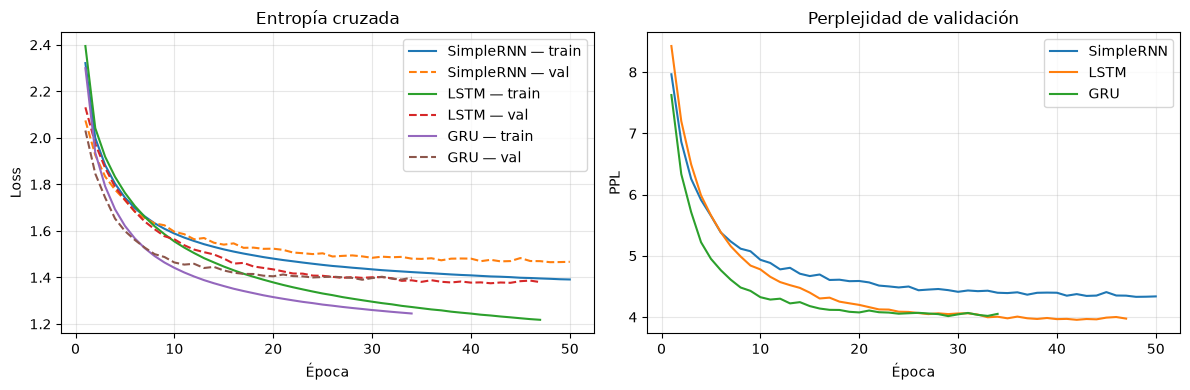

Modelo seleccionado: LSTM


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name, history in histories.items():
    epochs = range(1, len(history["loss"]) + 1)

    axes[0].plot(epochs, history["loss"], label=f"{name} — train")
    axes[0].plot(
        epochs, history["val_loss"], "--", label=f"{name} — val"
    )
    axes[1].plot(
        epochs, np.exp(history["val_loss"]), label=name
    )

axes[0].set(
    title="Entropía cruzada", xlabel="Época", ylabel="Loss"
)
axes[1].set(
    title="Perplejidad de validación", xlabel="Época", ylabel="PPL"
)

for ax in axes:
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

best_name = comparison.iloc[0]["modelo"]
best_model = models[best_name]
best_model.eval()

print("Modelo seleccionado:", best_name)

## 7. Generación de texto
Se utilizan los últimos 100 caracteres como contexto, sin agregar padding (los modelos admiten secuencias de longitud variable). `<UNK>` se excluye de las opciones de generación y se renormalizan las probabilidades.

- **Greedy:** elige el carácter más probable en cada paso.
- **Beam search determinístico:** conserva las `k` continuaciones con mayor suma de log-probabilidades. Explora varias hipótesis, sin garantizar la mejor secuencia global.
- **Beam search estocástico:** muestrea `k` continuaciones sin reemplazo entre las expansiones del beam. Siguiendo la idea del notebook base, aplica la temperatura a los puntajes acumulados para definir las probabilidades de selección; conserva los puntajes originales para ordenar las salidas.

Una temperatura baja concentra la selección en candidatos de mayor puntaje, mientras que una alta permite más diversidad, con posible pérdida de coherencia. Todas las continuaciones tienen la misma longitud, por lo que no es necesario normalizar el puntaje por longitud.

In [9]:
def encode_seed(seed):
    seed = unicodedata.normalize("NFC", seed).lower()
    seed = re.sub(r"\s+", " ", seed)
    if not seed.strip():
        raise ValueError("Ingresar un texto inicial no vacío.")
    unknown = set(seed) - set(char2idx)
    if unknown:
        raise ValueError(f"Caracteres fuera del vocabulario: {unknown}")
    return seed, [char2idx[c] for c in seed]


def next_probs(model, sequences):
    # Dentro de cada beam todas las secuencias tienen la misma longitud.
    batch = np.array([seq[-CONTEXT:] for seq in sequences], dtype=np.int32)
    model.eval()
    with torch.no_grad():
        x = torch.as_tensor(batch, dtype=torch.long, device=device)
        logits = model(x)[:, -1, :]
        probs = torch.softmax(logits, dim=-1).cpu().numpy().astype(np.float64)
    probs[:, 0] = 0  # No generar UNK.
    return probs / probs.sum(axis=1, keepdims=True)


def greedy_search(model, seed, n_chars=200):
    seed, tokens = encode_seed(seed)
    generated = []
    for _ in range(n_chars):
        token = int(np.argmax(next_probs(model, [tokens])[0]))
        tokens.append(token)
        generated.append(idx2char[token])
    return seed + "".join(generated)


def beam_search(model, seed, n_chars=200, width=3,
                stochastic=False, temperature=1.0, random_seed=SEED):
    if temperature <= 0 or not 1 <= width <= len(chars):
        raise ValueError("Usar temperatura > 0 y un beam entre 1 y la cantidad de caracteres.")

    seed, tokens = encode_seed(seed)
    sequences = [tokens]
    scores = np.array([0.0])
    rng = np.random.default_rng(random_seed)

    for _ in range(n_chars):
        probs = next_probs(model, sequences)
        log_probs = np.log(np.clip(probs, 1e-12, 1.0))
        log_probs[:, 0] = -np.inf
        candidate_scores = (scores[:, None] + log_probs).ravel()
        valid = np.flatnonzero(np.isfinite(candidate_scores))

        if stochastic:
            weights = candidate_scores[valid] / temperature
            weights = np.exp(weights - weights.max())
            weights = np.maximum(weights, np.finfo(float).tiny)
            weights /= weights.sum()
            selected = rng.choice(valid, size=width, replace=False, p=weights)
        else:
            selected = valid[np.argsort(candidate_scores[valid])[-width:][::-1]]

        # Cada candidato identifica una secuencia padre y un carácter nuevo.
        sequences = [sequences[int(i // vocab_size)] + [int(i % vocab_size)]
                     for i in selected]
        scores = candidate_scores[selected]

    order = np.argsort(scores)[::-1]
    return [("".join(idx2char[t] for t in sequences[i]), float(scores[i]))
            for i in order]

## 8. Comparación de estrategias y temperaturas
Se generan 200 caracteres con los mismos dos comienzos y el mismo modelo. En beam search se muestra la hipótesis de mayor puntaje entre las conservadas y se repite cada temperatura con dos semillas aleatorias para no basarse en una única muestra.

In [10]:
prompts = ["el viajero ", "aquella noche "]
N_CHARS = 200
BEAM_WIDTH = 3
samples = []

for prompt in prompts:
    samples.append({
        "inicio": prompt, "estrategia": "greedy", "temperatura": None,
        "semilla": None, "texto": greedy_search(best_model, prompt, N_CHARS),
    })
    output = beam_search(best_model, prompt, N_CHARS, width=BEAM_WIDTH)
    samples.append({
        "inicio": prompt, "estrategia": "beam determinístico", "temperatura": None,
        "semilla": None, "texto": output[0][0],
    })
    for temperature in [0.5, 1.0, 1.5]:
        for random_seed in [42, 123]:
            output = beam_search(
                best_model, prompt, N_CHARS, width=BEAM_WIDTH,
                stochastic=True, temperature=temperature, random_seed=random_seed,
            )
            samples.append({
                "inicio": prompt, "estrategia": "beam estocástico",
                "temperatura": temperature, "semilla": random_seed,
                "texto": output[0][0],
            })

samples_df = pd.DataFrame(samples)
for sample in samples:
    print(f"\n{sample['estrategia']} | T={sample['temperatura']} | semilla={sample['semilla']}")
    print(sample["texto"])

samples_df.to_csv(OUTPUT_DIR / "textos_generados.csv", index=False)


greedy | T=None | semilla=None
el viajero para su partida de la partida del mar del "mongolia" y el parsi sin decir de los mares, el capitán se había para el pasajero que se había apuesta y picaporte no se presentó en la mano de la partida de

beam determinístico | T=None | semilla=None
el viajero para precipientas mil libras por una compañía a las ocho del reform-club. picaporte se había reconocimiento algunas veinte mil libras por una compañía a las ocho del reform-club. picaporte se había re

beam estocástico | T=0.5 | semilla=42
el viajero que se presentaba a la vista y sus compañeros de los viajeros, que no se presentaba a la velocidad del reform-club, que se había partida del momento en las compañeros, y después de haber sido mister f

beam estocástico | T=0.5 | semilla=123
el viajero comprendió que no había reconocimiento a medio de los viajeros, que estaban después de haber salido de los pasajeros del reform-club, que se hallaba a su amo, y se había trata de las cuatro horas, 

## 9. Resultados y conclusiones
La siguiente celda resume los valores reales del experimento ejecutado. Las métricas del entrenamiento anterior no se reutilizan porque cambió el corpus.

Después de ejecutar, completar el análisis cualitativo con fragmentos de las nuevas salidas. No se presupone que LSTM gane ni que una temperatura particular sea mejor.

In [11]:
winner = comparison.iloc[0]
print(f"Modelo seleccionado: {winner['modelo']}; perplejidad: {winner['val_perplexity']:.4f}")
for _, other in comparison.iloc[1:].iterrows():
    improvement = 100 * (1 - winner["val_perplexity"] / other["val_perplexity"])
    print(f"Reducción de perplejidad frente a {other['modelo']}: {improvement:.2f}%")
for _, row in comparison.iterrows():
    name = row["modelo"]
    losses = histories[name]["val_loss"]
    # La condición también puede alcanzarse justo en la última época permitida.
    stopped = len(losses) - (int(np.argmin(losses)) + 1) >= PATIENCE
    print(f"{name}: {int(row['epocas'])} épocas; mejor época "
          f"{int(row['mejor_epoca'])}; detención por paciencia: {stopped}; "
          f"parámetros: {int(row['parametros']):,}; tiempo: {row['minutos']:.2f} min.")

Modelo seleccionado: LSTM; perplejidad: 3.9544
Reducción de perplejidad frente a GRU: 1.51%
Reducción de perplejidad frente a SimpleRNN: 8.66%
LSTM: 47 épocas; mejor época 42; detención por paciencia: True; parámetros: 93,409; tiempo: 2.48 min.
GRU: 34 épocas; mejor época 29; detención por paciencia: True; parámetros: 72,673; tiempo: 1.53 min.
SimpleRNN: 50 épocas; mejor época 48; detención por paciencia: False; parámetros: 31,201; tiempo: 1.21 min.


## 9. Conclusiones

### Comparación de modelos

| Modelo | Parámetros | Épocas | Mejor época | Perplejidad de validación | Tiempo |
|---|---:|---:|---:|---:|---:|
| SimpleRNN | 31.201 | 50 | 48 | 4,3295 | 1,21 min |
| LSTM | 93.409 | 47 | 42 | **3,9544** | 2,48 min |
| GRU | 72.673 | 34 | 29 | 4,0149 | 1,53 min |

LSTM obtuvo la menor perplejidad y se eligió para generar los textos. La diferencia fue del 8,66 % respecto de SimpleRNN, pero de solo el 1,51 % frente a GRU.

GRU quedó cerca de LSTM usando menos parámetros y menos tiempo de entrenamiento. Si se considera el costo además de la perplejidad, también sería una buena opción para este caso. SimpleRNN fue la más pequeña y rápida, aunque tuvo el peor resultado de validación.

Durante el entrenamiento, GRU mejoró más rápido al principio. LSTM necesitó más épocas, pero terminó alcanzando un mejor resultado. En ambos casos, la pérdida de entrenamiento siguió bajando cuando la de validación ya mostraba pocas mejoras. La detención temprana se activó en las épocas 47 y 34, y se recuperaron los pesos de las épocas 42 y 29. SimpleRNN llegó al máximo de 50 épocas, con su mejor resultado en la 48.

### Generación de texto

Con **greedy search**, el modelo generó palabras reconocibles y nombres del libro, pero también frases mal construidas y repeticiones como “la partida del mar”. Los dos comienzos elegidos llevaron a continuaciones bastante parecidas.

El **beam search determinístico** no mejoró claramente los textos. Con “aquella noche”, repitió “porque en la mañana” durante gran parte de la salida. Con “el viajero”, repitió fragmentos más largos sobre libras y el reform-club. En estos ejemplos, explorar más opciones no alcanzó para evitar las repeticiones.

El **beam search estocástico** permitió obtener textos más variados. Al cambiar la temperatura se observaron estas diferencias:

- **0,5:** las palabras fueron, en general, más reconocibles, aunque siguieron apareciendo frases incorrectas, como “que se habían apareció”.
- **1,0:** hubo más variedad e intentos de diálogo, como “—señor —respondió mister fogg”. También aparecieron palabras inventadas y frases sin conexión.
- **1,5:** aumentaron los errores y las palabras deformadas, como “repatillas” y “fríficco”, lo que hizo más difícil leer las continuaciones.

Entre las muestras generadas, las temperaturas 0,5 y 1,0 dieron resultados más legibles. De todas formas, ninguna estrategia logró mantener una historia coherente durante los 200 caracteres.

### Observaciones finales

Los modelos aprendieron parte del vocabulario y de las expresiones del libro, pero todavía tuvieron dificultades para armar oraciones y conectar ideas. Esto también muestra que una menor perplejidad no asegura que el texto generado tenga sentido.

El experimento se limitó a un libro y a un contexto de 100 caracteres. Además, se realizó un entrenamiento por arquitectura y la comparación de los textos se basó en dos comienzos y dos semillas por temperatura. Por eso, los resultados describen lo ocurrido en estas pruebas y no permiten concluir que LSTM sea siempre mejor.

Para este trabajo, LSTM fue la mejor según la perplejidad, mientras que GRU consiguió un resultado cercano con menor costo. Como siguiente prueba, sería interesante aumentar el contexto y revisar si eso ayuda a mantener la continuidad del texto.